# 06 · Expectation and Variance

**Session 7 · Tue Sep 29 · 2 hours**

Two ideas, and the notation that goes with them: `E[X]` and `Var(X)`. You already know both
intuitively; this notebook attaches the symbols to the intuitions so formulas stop being opaque.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
DATA = Path.cwd() / "data" if (Path.cwd() / "data").exists() else Path.cwd().parent / "data"
rng = np.random.default_rng(42)   # same seed => same numbers every time you run this

## 1 · Expectation `E[X]` is a weighted average

`E[X]` — "the expected value of X" — is the long-run average of X. The name is unfortunate: it is
often a value you should never *expect* to see.

A fair die has `E[X] = 3.5`. You will never roll 3.5.

In [2]:
die = rng.integers(1, 7, 500_000)
print(f"simulated mean: {die.mean():.4f}")
print(f"E[X] by hand:   {sum(v * (1/6) for v in range(1, 7)):.4f}")
print()
print("E[X] = Σ (value × probability of that value)")
print("     = 1(1/6) + 2(1/6) + 3(1/6) + 4(1/6) + 5(1/6) + 6(1/6) = 3.5")

simulated mean: 3.5004
E[X] by hand:   3.5000

E[X] = Σ (value × probability of that value)
     = 1(1/6) + 2(1/6) + 3(1/6) + 4(1/6) + 5(1/6) + 6(1/6) = 3.5


### Where this becomes a business tool

Expectation is how you price risk. Consider a $200,000 loan with a 9% default probability, where
default loses you 60% of principal and repayment earns 5% interest.

In [3]:
principal, p_default, lgd, rate = 200_000, 0.09, 0.60, 0.05

outcome_default = -principal * lgd          # you lose 60% of principal
outcome_repaid  =  principal * rate         # you earn interest

ev = p_default * outcome_default + (1 - p_default) * outcome_repaid

print(f"if it defaults  ({p_default:.0%} chance): ${outcome_default:>12,.0f}")
print(f"if it repays    ({1-p_default:.0%} chance): ${outcome_repaid:>12,.0f}")
print(f"\nE[profit] = ${ev:,.0f}")
print("\nNeither outcome IS the expected value. It is what you'd average over many such loans.")

if it defaults  (9% chance): $    -120,000
if it repays    (91% chance): $      10,000

E[profit] = $-1,700

Neither outcome IS the expected value. It is what you'd average over many such loans.


That last line is the whole concept. `E[X]` describes a *portfolio*, never an individual case. Which
is precisely why a single loan going bad tells you nothing about whether the pricing was right — and
why you need many observations before you can judge.

## 2 · Variance `Var(X)` — how much it bounces

Expectation tells you the center. Variance tells you how far from it you typically land. Two
portfolios can have identical expected returns and completely different risk.

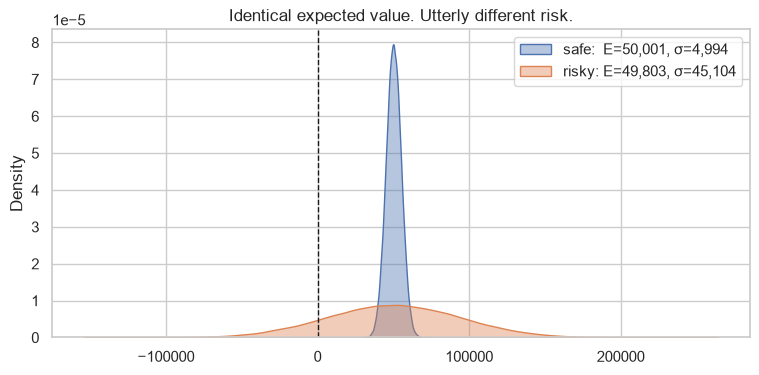

P(losing money), safe:  0.000%
P(losing money), risky: 13.486%


In [4]:
safe  = rng.normal(50_000, 5_000,  100_000)     # same mean...
risky = rng.normal(50_000, 45_000, 100_000)     # ...very different spread

fig, ax = plt.subplots(figsize=(9, 4))
sns.kdeplot(safe,  fill=True, alpha=.4, label=f"safe:  E={safe.mean():,.0f}, σ={safe.std():,.0f}", ax=ax)
sns.kdeplot(risky, fill=True, alpha=.4, label=f"risky: E={risky.mean():,.0f}, σ={risky.std():,.0f}", ax=ax)
ax.axvline(0, color="k", ls="--", lw=1)
ax.set_title("Identical expected value. Utterly different risk.")
ax.legend(); plt.show()

print(f"P(losing money), safe:  {np.mean(safe  < 0):.3%}")
print(f"P(losing money), risky: {np.mean(risky < 0):.3%}")

**`E[X]` alone is never a sufficient description.** Any report quoting an expected return without a
spread is hiding the thing you actually need to make a decision.

## 3 · The rules you will see in lectures

Four identities, each demonstrated rather than asserted. `a` and `b` are constants.

In [5]:
X = rng.normal(10, 3, 200_000)
a, b = 4, 7

checks = [
    ("E[aX + b] = a·E[X] + b",      (a*X + b).mean(),  a*X.mean() + b),
    ("Var(aX + b) = a²·Var(X)",     (a*X + b).var(),   a**2 * X.var()),
    ("Var(X) = E[X²] − (E[X])²",    X.var(),           (X**2).mean() - X.mean()**2),
]
for name, simulated, formula in checks:
    print(f"{name:32s} simulated {simulated:>14,.3f}   formula {formula:>14,.3f}")

Y = rng.normal(-4, 5, 200_000)   # independent of X
print(f"\n{'Var(X + Y) = Var(X) + Var(Y)':32s} simulated {(X+Y).var():>14,.3f}"
      f"   formula {X.var() + Y.var():>14,.3f}   (independence required!)")

E[aX + b] = a·E[X] + b           simulated         46.963   formula         46.963
Var(aX + b) = a²·Var(X)          simulated        144.213   formula        144.213
Var(X) = E[X²] − (E[X])²         simulated          9.013   formula          9.013

Var(X + Y) = Var(X) + Var(Y)     simulated         34.116   formula         34.042   (independence required!)


### Two things worth noticing

**Adding a constant does not change variance.** `Var(aX + b) = a²Var(X)` — the `b` vanishes. Shifting
every value by $7 moves the center but changes no spread. Obvious once stated, easy to miss in a formula.

**Variances add, standard deviations do not.** `Var(X+Y) = Var(X)+Var(Y)` for independent variables,
so `σ` of the sum is `√(σ₁² + σ₂²)`, not `σ₁ + σ₂`. This is why diversification works: combine
independent risks and the total standard deviation grows like `√n` rather than `n`.

In [6]:
# Diversification, demonstrated.
sd_one = 45_000
for n in (1, 4, 25, 100):
    loans = rng.normal(50_000, sd_one, (60_000, n))
    port  = loans.mean(axis=1)                 # average return per loan in the portfolio
    print(f"n={n:>4}  σ of portfolio average = {port.std():>9,.0f}   "
          f"(theory {sd_one/np.sqrt(n):>9,.0f})")
print("\nRisk per loan falls as σ/√n. Quadruple the loans, halve the volatility.")

n=   1  σ of portfolio average =    44,975   (theory    45,000)
n=   4  σ of portfolio average =    22,441   (theory    22,500)
n=  25  σ of portfolio average =     9,006   (theory     9,000)


n= 100  σ of portfolio average =     4,499   (theory     4,500)

Risk per loan falls as σ/√n. Quadruple the loans, halve the volatility.


That `σ/√n` is about to become the single most important formula in the course. In the next notebook
it gets a name — the **standard error** — and it is the reason statistical inference is possible at all.

## Your turn

**Exercise 1.** An insurance policy: premium $1,200/yr. A claim occurs with probability 4% and costs
$22,000 on average. What is the expected profit per policy? How many policies before the *average*
profit per policy is within $100 of that expectation (use simulation)?

In [7]:
# your code here

In [ ]:
prem, p_claim, claim = 1_200, 0.04, 22_000
ev = prem - p_claim * claim
print(f"E[profit per policy] = ${ev:,.0f}")

sd = np.sqrt(p_claim*(1-p_claim)) * claim     # σ of the claim cost
print(f"σ per policy ≈ ${sd:,.0f}  -- enormous relative to the ${ev:,.0f} margin")

for n in (100, 1_000, 10_000, 50_000):
    sims = np.array([(prem - rng.binomial(1, p_claim, n)*claim).mean() for _ in range(400)])
    print(f"n={n:>6,}  P(|avg - EV| < $100) = {np.mean(np.abs(sims-ev) < 100):.1%}")

# Around 10,000-50,000 policies. That is the actual reason insurers must be large:
# the per-policy variance dwarfs the per-policy margin, so only volume makes the
# expected value a reliable description of what you'll actually collect.

**Exercise 2.** Confirm that `Var(X − Y) = Var(X) + Var(Y)` for independent X and Y — note the **plus**
on the right despite the minus on the left. Why does subtracting not reduce the variance?

In [9]:
# your code here

In [ ]:
X = rng.normal(10, 3, 300_000)
Y = rng.normal(20, 4, 300_000)
print(f"Var(X - Y) simulated = {(X-Y).var():,.3f}")
print(f"Var(X) + Var(Y)      = {X.var() + Y.var():,.3f}")

# Variance measures SPREAD, and spread has no direction. Subtracting a noisy quantity
# injects its noise just as surely as adding it does -- two sources of uncertainty
# always compound. This is why a difference between two measured groups is noisier
# than either group alone, which matters directly for hypothesis testing.

## What you did today

- `E[X]` as a weighted average that describes a portfolio, never an individual.
- `Var(X)` as the missing half of any honest summary.
- The four algebra rules, verified by simulation.
- **`σ/√n`** — diversification, and a preview of the standard error.

**Next:** `07_clt_and_standard_error.ipynb` — the centerpiece of the whole five weeks.